# Código mínimo para Random Forest

In [ ]:
# comprobamos que tenemos las librerias instaladas desde la terminal con pip show
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.datasets  import load_breast_cancer

data = load_breast_cancer()

print(f"El tipo de dato cargado es", type(data))
print(f"Las variables explicativas son", data.feature_names)
print(f"La variable predictora", data.target_names)
print(f"Tamaño dataset", data.data.shape)

X = data.data
y = data.target

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)

train_tree = model_tree.fit(X_train,y_train)

In [18]:
from sklearn.metrics import accuracy_score

predict_tree_train = model_tree.predict(X_train)

accuracy_score_tree_train = accuracy_score(y_train,predict_tree_train)

print(f"El accuracy para el modelo con los datos de entrenamiento es", accuracy_score_tree_train)

El accuracy para el modelo con los datos de entrenamiento es 1.0


In [20]:
predict_tree_test = model_tree.predict(X_test)

accuracy_score_tree_test = accuracy_score(y_test,predict_tree_test)

print(f"El accuracy para el modelo con los datos de test es", accuracy_score_tree_test)

El accuracy para el modelo con los datos de test es 0.9473684210526315


Como vimos en teoría, los modelos de ensemble, concretamente el Random Forest reducen la varianza del modelo. La varianza del modelo hace referencia a 1 de las 2 fuentes de error que puede tener un modelo. En este caso, es sensible a los datos de entrenamiento. Esto produce un efecto-> overfitting. Ya que al modificar y predecir en datos nuevos, como los de test, el modelo acierta menos.

El efecto de disminución de varianza en un Random Forest se debe a que se promedia las predicciones de distintos modelos diferentes que entrenan en paralelo (tienen errores diferentes al tener muestras diferentes del dataset original de train). Esto produce un efecto de disminución de varianza, ya que cada modelo tiene errores diferentes y ese promedio hace que se cancele el error. Además, en cada nodo de los distintos árboles que entrenan en el RF se elige de manera aleatorio un conjunto de variables. Esto unido al boostrap de muestras hace que cada árbol sea muy diferente. Por ejemplo, si la edad es una variable muy predictiva y obligo a un árbol a no verla en un nodo, esto le obliga a buscar otras variables, patrones... En definitiva, hay una mayor reducción de varianza, produciendo que el modelo no sea tan sensible a los datos de entrenamiento

In [21]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(n_estimators=100, random_state=42)

# se entrena el Random Forest de manera análoga al Árbol de Decisión
model_train = model_RF.fit(X_train, y_train)

In [22]:
# como trabaja en datos que ya ha visto
predict_RF_train = model_RF.predict(X_train)

accuracy_score_RF_train = accuracy_score(y_train, predict_RF_train)

print(f"El accuracy para el modelo con los datos de train es", accuracy_score_RF_train)

El accuracy para el modelo con los datos de train es 1.0


In [23]:
# ¿Y con datos nuevos?
predict_RF_test = model_RF.predict(X_test)

accuracy_score_RF_test = accuracy_score(y_test, predict_RF_test)

print(f"El accuracy para el modelo con los datos de train es", accuracy_score_RF_test)

El accuracy para el modelo con los datos de train es 0.9649122807017544


Se aprecia como el modelo de ensemble permite que se tenga menos sensibilidad a los datos de entrenamiento-> reducir la varianza, tal y como se esperaba. Esto es el efecto de promediar las predicciones de distintos árboles.

In [26]:
# atributo interesante del RF
feature_importance= model_RF.feature_importances_

print(f"Variables de los datos", data.feature_names)
print(f"Variables más importantes", feature_importance)

Variables de los datos ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Variables más importantes [0.04870337 0.01359088 0.05326975 0.04755501 0.00728533 0.01394433
 0.06800084 0.10620999 0.00377029 0.00388577 0.02013892 0.00472399
 0.01130301 0.02240696 0.00427091 0.00525322 0.00938583 0.00351326
 0.00401842 0.00532146 0.07798688 0.02174901 0.06711483 0.15389236
 0.01064421 0.02026604 0.0318016  0.14466327 0.01012018 0.00521012]


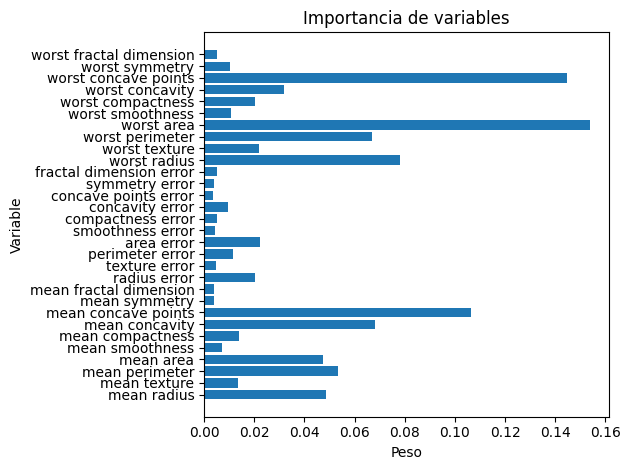

In [28]:
import matplotlib.pyplot as plt

# gráfico de barras horizontal
plt.barh(data.feature_names, feature_importance)
plt.title("Importancia de variables")
plt.ylabel("Variable")
plt.xlabel("Peso")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# se sacan los indices que ordenan las importancias de menor a mayor-> luego el barh dibuja el gráfico de abajo a arriba
feature_importance_sort = np.argsort(feature_importance)

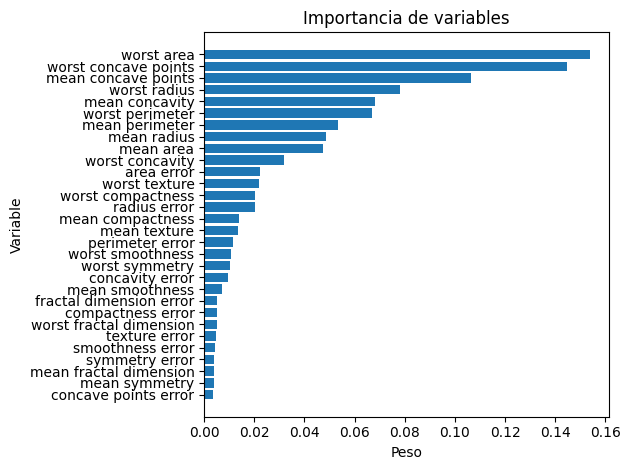

In [30]:
plt.barh(data.feature_names[feature_importance_sort], feature_importance[feature_importance_sort])
plt.title("Importancia de variables")
plt.ylabel("Variable")
plt.xlabel("Peso")
plt.tight_layout()
plt.show()

En el cáncer de mama el área del tumor es uno de los indicadores más claros de malignidad